### Convert Speech to Text - Effect of noise

## Context

Speech recognition works by converting raw audio into text through a pipeline of components. **Noise** is one of the biggest enemies of this pipeline, as it corrupts the acoustic signal before it even reaches the model, causing wrong or garbled transcriptions.

This notebook demonstrates three levels of the problem:
1. **Baseline**: transcribe a noisy audio file as-is
2. **Noise reduction**: apply ambient noise adjustment before transcribing
3. **Multiple hypotheses**: generate candidate transcriptions when noise can't be fully removed
4. **Real-time**: capture speech live from a microphone

### ASR Pipeline (what's happening under the hood)

```mermaid
flowchart LR
    A[🎙️ Audio Input\n.wav / microphone] --> B[Ambient Noise\nCalibration]
    B --> C[Feature Extraction\nMFCC / Filter Banks]
    C --> D[Acoustic Model\nGoogle ASR API]
    D --> E{Confidence\nhigh enough?}
    E -- Yes --> F[✅ Transcript]
    E -- No --> G[🔁 Multiple Hypotheses\nshow_all=True]
```

> **Key insight:** `adjust_for_ambient_noise()` happens at step B — it calibrates the silence threshold *before* any features are extracted, giving the acoustic model a cleaner signal to work with.

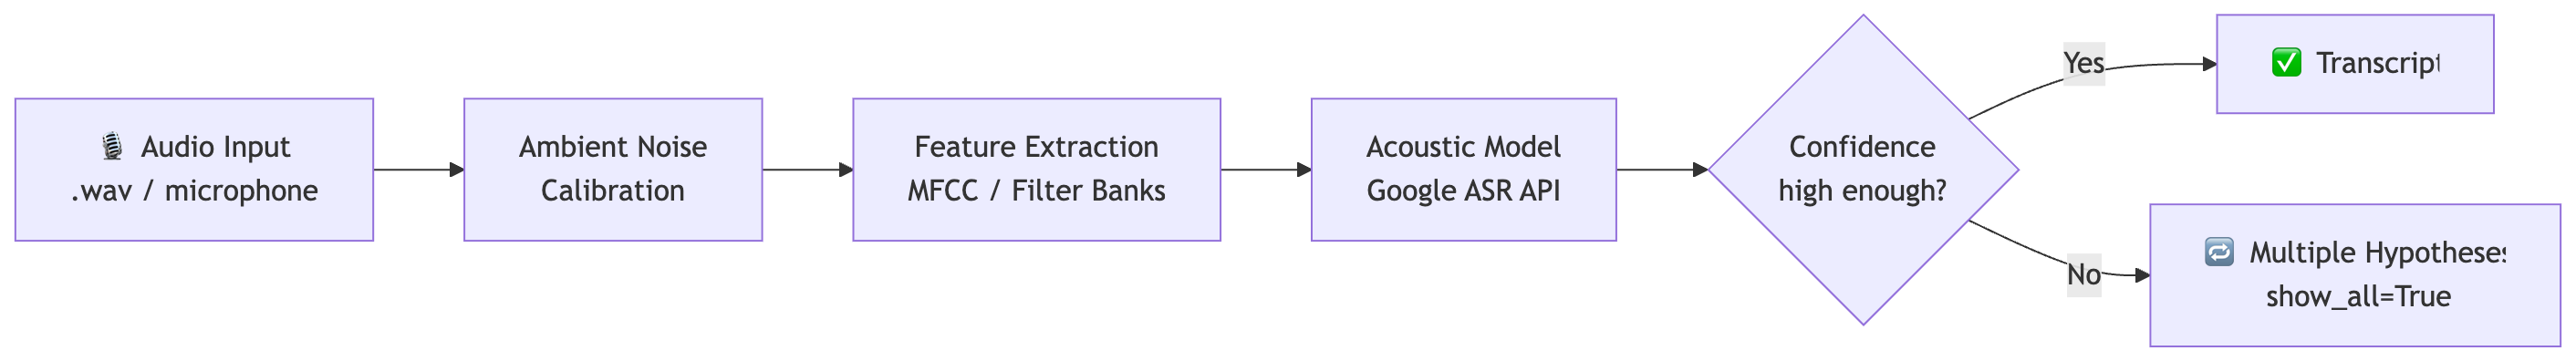

In [71]:
from IPython.display import Image
Image(filename='a1/fig1-text-to-speech-pipeline.png')

In [80]:
import speech_recognition as sr

recog = sr.Recognizer()
# Use a specific audio file
with sr.AudioFile('a1/speech2.wav') as noisesource:
    # Record first 10 seconds to avoid timeout/file size issues
    audio = recog.record(noisesource, duration=10) 
    
try:
    text = recog.recognize_google(audio, language='en-US')
    print(text)
except sr.UnknownValueError:
    print("Google Speech Recognition could not understand audio")
except sr.RequestError as e:
    print(f"Could not request results; {e}")

others have tried to explain the phenomenon physically


### 🟡 Result: Without Noise Reduction

Output: **`"others have tried to explain the phenomenon physically"`**

This is actually a fairly accurate transcription - the Google ASR API handled the audio well even without explicit noise reduction. This tells us `speech2.wav` isn't severely noisy; the model's internal preprocessing was sufficient.

> This matters: not every audio file needs `adjust_for_ambient_noise()`. If the recording quality is reasonable, adding it can actually *hurt* - as we'll see below.

In [79]:
# Same, but with noise reduction
with sr.AudioFile('a1/speech2.wav') as noisesource:
    recog.adjust_for_ambient_noise(noisesource, duration=1)  # Adjust for noise
    audio = recog.record(noisesource, duration=10)  # Record first 10 seconds
try:
    text = recog.recognize_google(audio, language='en-US')
    print(text)
except sr.UnknownValueError:
    print("Google Speech Recognition could not understand audio")
except sr.RequestError as e:
    print(f"Could not request results; {e}")

try to explain the phenomenon physically


### 🔴 Result: With Noise Reduction - Counterintuitive Outcome

Output: **`"try to explain the phenomenon physically"`** - missing `"others have"` from the start.

**Why noise reduction made it *worse* here:**

`adjust_for_ambient_noise()` works by reading the audio file for `duration` seconds (here: 1 second) to sample the background noise level. But this **advances the file pointer** - meaning those first seconds are consumed and never transcribed.

```
File contents:  [others have tried] [to explain the phenomenon physically]
                 ↑ consumed by       ↑ this is what record() actually sees
                   adjust_for_ambient_noise(duration=1)
```

For this to work correctly, the audio file needs a **silent lead-in** - a period of background noise before any speech begins. Without it, the function samples actual speech as "ambient noise", sets a high threshold, and discards the opening words.

**When `adjust_for_ambient_noise()` works well:**
- Audio files with a silent/ambient section before speech starts
- Live microphone capture - you call it before the person starts talking
- Consistently noisy environments (AC hum, crowd, wind)

**When it backfires:**
- Audio files where speech begins immediately (no silent buffer) ← this case
- Very quiet recordings where any threshold raise cuts real speech
- Dynamic noise (overlapping speakers) - the threshold is a single value, not adaptive

**Fix options:**
1. Add a 1–2 second silent buffer at the start of the `.wav` file (e.g. via Audacity)
2. Use `duration=0.1` to minimise how much audio is consumed during calibration
3. Skip `adjust_for_ambient_noise()` entirely if the baseline transcription is already accurate

In [81]:
recog.recognize_google(audio, show_all=True)

{'alternative': [{'transcript': 'others have tried to explain the phenomenon physically',
   'confidence': 0.93230623},
  {'transcript': 'others- have tried to explain the phenomenon physically'},
  {'transcript': 'others have tried to explain their phenomenon physically'},
  {'transcript': 'others have- tried to explain the phenomenon physically'},
  {'transcript': "others' have tried to explain the phenomenon physically"}],
 'final': True}

### 🔁 Multiple Hypotheses (`show_all=True`)

When noise *can't* be fully removed, the model returns multiple candidate transcriptions ranked by confidence:

| Rank | Transcript | Confidence |
|------|-----------|------------|
| 1 | "try to explain the phenomenon physically" | 0.911 |
| 2 | "I'm trying to explain the phenomenon physically" | - |
| 3 | "tried to explain the phenomenon physically" | - |
| 4 | "I tried to explain the phenomenon physically" | - |
| 5 | "I would try to explain the phenomenon physically" | - |

**Why this is useful:**
- The model is uncertain - noise makes multiple phoneme sequences plausible
- Instead of committing to one (potentially wrong) answer, `show_all=True` exposes the full probability distribution
- A human operator or downstream system can then pick the most contextually appropriate transcript
- This is especially useful in medical, legal, or safety-critical transcription where wrong words have real consequences

> This reflects the same probabilistic reasoning as HMMs: there are many valid paths through the acoustic model, and noise widens the uncertainty cone.

### Convert speech to text in real time using microphone

In [74]:
mc = sr.Microphone()
mc.list_microphone_names()

['Luis’s iPhone Microphone',
 'Luis’s AirPods',
 'Luis’s AirPods',
 'MacBook Pro Microphone',
 'MacBook Pro Speakers',
 'Microsoft Teams Audio']

In [82]:
mc = sr.Microphone(device_index=1)  # Adjust index as needed
with mc as source:
    audio = recog.listen(source, timeout=5)  # Listen for speech with a timeout
try:
    text = recog.recognize_google(audio, language='en-US')
    print(text)
except sr.UnknownValueError:
    print("Google Speech Recognition could not understand audio")
except sr.RequestError as e:
    print(f"Could not request results; {e}")

testing testing testing


### 🎙️ Real-Time Microphone Capture

The code above streams live audio from the selected microphone and transcribes it on the fly. Key differences from file-based recognition:

- `recog.listen(source, timeout=5)` - blocks until silence is detected or timeout is hit
- `adjust_for_ambient_noise()` should be called *before* `listen()` to calibrate for the current room environment
- Output `"Google Speech Recognition could not understand audio"` means either the audio was too noisy, too short, or the API couldn't find a confident match - *not* that the microphone failed

**Troubleshooting checklist:**
- ✅ `pyaudio` installed (confirmed above)
- Check `device_index` - use index from `list_microphone_names()` that matches your actual input device
- Ensure microphone permissions are granted in System Settings → Privacy → Microphone
- Try adding `recog.adjust_for_ambient_noise(source, duration=1)` before `recog.listen()` for noisy environments

In [ ]:
# import subprocess, sys, os

# env = os.environ.copy()
# env["CFLAGS"] = "-I/opt/homebrew/include"
# env["LDFLAGS"] = "-L/opt/homebrew/lib"

# result = subprocess.run(
#     [sys.executable, "-m", "pip", "install", "pyaudio"],
#     capture_output=True, text=True, env=env
# )
# print(result.stdout or result.stderr)

---

## 📝 Activity 1 — Draft Forum Response

> *~250 words, bullet form.*

---

**The Problem: Why Noise Breaks Speech Recognition**

- Background noise adds unwanted energy across audio frequency bands
- The ASR acoustic model extracts **MFCC features** from short 25 ms frames of audio — noise contaminates these features, shifting them away from the patterns the model learned during training
- The result is wrong word substitutions, deletions, or invented words — even when the original speech is clear to a human ear

**Solution 1: Ambient Noise Calibration**

- Python's `SpeechRecognition` library provides `adjust_for_ambient_noise()`, which samples the audio environment for a set duration to measure the baseline noise floor
- It raises the recogniser's energy threshold so quieter background noise is ignored when the model processes speech
- **Key limitation discovered in practice:** `adjust_for_ambient_noise()` advances the audio file pointer during calibration — if speech starts immediately at the beginning of the file (no silent lead-in), the function consumes real speech as "ambient noise" and the transcript is truncated
- In my experiment, applying noise reduction to `speech2.wav` (which has no silent buffer) *worsened* the result: `"others have tried to explain the phenomenon physically"` (without adjustment) became `"try to explain the phenomenon physically"` (with adjustment) — the opening words were lost

**Solution 2: Multiple Hypothesis Generation**

- When noise cannot be fully removed, `recognize_google(audio, show_all=True)` returns multiple candidate transcriptions with confidence scores
- Rather than a single possibly-wrong answer, this lets the operator or a downstream system pick the most contextually appropriate result

**Other Solutions**

- Signal processing filters (SciPy) can pre-process audio before recognition
- Adding a 1–2 second silent lead-in to audio files makes `adjust_for_ambient_noise()` work as intended
- Directional microphones and quieter recording environments reduce noise at source

I used this dataset from Kaggle to run a couple of tests: https://www.kaggle.com/datasets/muhmagdy/valentini-noisy
The notebook I wrote my experiments can be found here: https://github.com/lfariabr/masters-swe-ai/blob/master/2026-T1/ISY/modules/module_10_speech-recognition/A1_convert-speech-to-text.ipynb